# PFM de Visualisation des données 

## Analyse du Risque de Santé

### Contexte du projet

Ce projet vise à explorer et visualiser les facteurs associés au risque de santé à partir d'un dataset comportant 12 variables. L'objectif principal est d'identifier les déterminants qui distinguent les personnes à risque de santé élevé de celles à risque faible.

### Objectifs

- Explorer la structure et la composition du dataset
- Comparer trois méthodes d'échantillonnage
- Réaliser des visualisations univariées, bivariées et multivariées
- Identifier les facteurs de risque principaux
- Interpréter les relations et interactions entre variables

### Structure du notebook

1. Chargement et exploration des données
2. Échantillonnage (aléatoire, systématique, stratifié)
3. Visualisations univariées
4. Visualisations bivariées
5. Visualisations multivariées
6. Synthèse et conclusions

---

## Chargement et aperçu des données

### Lecture du dataset

Nous chargeons le dataset à partir du fichier source et affichons les premières lignes pour comprendre sa structure.

In [182]:
import pandas as pd

In [10]:
df = pd.read_csv(r"C:\Users\merry b\Downloads\Lifestyle_and_Health_Risk_Prediction_Dataset.csv")

In [12]:
df.shape

(5000, 12)

### Exploration initiale du dataset

#### Informations générales
- **Nombre d'observations** : [à compléter]
- **Nombre de variables** : 12
- **Types de variables** : quantitatives et qualitatives

#### Description des variables

**Variables quantitatives :**
- `age` : Âge de l'individu
- `weight` : Poids en kg
- `height` : Taille en cm
- `sleep` : Durée du sommeil en heures
- `bmi` : Indice de masse corporelle

**Variables qualitatives :**
- `health_risk` : Risque de santé (high/low) - **Variable cible**
- `profession` : Profession de l'individu
- `exercise` : Niveau d'exercice physique (none, low, medium, high)
- `married` : Statut matrimonial (yes/no)
- `alcohol` : Consommation d'alcool (yes/no)
- `smoking` : Tabagisme (yes/no)
- `sugar_intake` : Consommation de sucre (low, medium, high)

In [14]:
df.head(10)

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high
5,25,96,160,medium,3.8,medium,no,no,yes,farmer,37.5,high
6,78,64,168,medium,9.9,high,no,no,yes,artist,22.7,high
7,38,76,194,low,6.6,medium,yes,no,yes,driver,20.2,high
8,56,58,158,medium,9.6,medium,no,no,yes,office_worker,23.2,low
9,75,94,147,none,8.1,medium,yes,no,no,farmer,43.5,high


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


### Statistiques descriptives

#### Variables quantitatives

Affichage des statistiques de base (moyenne, médiane, écart-type, min, max) pour comprendre la distribution des variables numériques.

In [18]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


### Vérification des valeurs manquantes

Nous vérifions la présence de valeurs manquantes dans le dataset pour assurer la qualité de nos analyses.



In [22]:
df.isnull().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

**Résultat** : Pas de valeurs manquantes

## Méthodes d'échantillonnage

Pour ce projet, nous devons sélectionner un échantillon de 500 observations à partir du dataset complet. Trois méthodes d'échantillonnage sont testées et comparées.

### Pourquoi l'échantillonnage ?

L'échantillonnage permet de :
- Réduire la complexité computationnelle
- Travailler avec un subset représentatif
- Comparer différentes approches méthodologiques

### Méthodes testées :
1. **Échantillonnage aléatoire simple**
2. **Échantillonnage stratifié** (méthode retenue)
3. **Échantillonnage par grappes**

In [24]:
sample_simple = df.sample(n=500, random_state=42)

### Échantillonnage aléatoire simple

#### Principe
Sélection aléatoire de 500 observations sans tenir compte de la structure du dataset.

#### Avantages
- Simplicité de mise en œuvre
- Chaque observation a la même probabilité d'être sélectionnée

#### Inconvénients
- Risque de déséquilibre dans la représentation des groupes health_risk
- Peut ne pas refléter la composition réelle de la population

In [26]:
sample_simple.describe()

,age,weight,height,sleep,bmi
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,49.658000,77.548000,172.306000,7.011600,26.893000
std,17.933216,19.356162,15.846849,1.396081,8.809346
min,18.000000,45.000000,145.000000,3.000000,11.500000
25%,35.000000,61.000000,159.000000,6.075000,19.700000
50%,50.000000,77.000000,173.000000,7.000000,26.100000
75%,65.250000,95.000000,186.000000,7.900000,32.625000
max,79.000000,109.000000,199.000000,10.000000,50.900000


On remarque que les valeurs statistiques sont trés proches de ceux du dataset initiale

In [28]:
from sklearn.model_selection import train_test_split

n = 500
test_size = 1 - (n / len(df))

sample_stratified, _ = train_test_split(
    df,
    test_size=test_size,
    stratify=df['health_risk'],
    random_state=42
)

### Échantillonnage stratifié (MÉTHODE RETENUE) ✓

#### Principe
Stratification selon la variable **health_risk** pour préserver les proportions des groupes dans l'échantillon.

#### Avantages
- Garantit une représentation proportionnelle des deux catégories de risque
- Améliore la précision des analyses comparatives
- Réduit la variance des estimations
- Permet des comparaisons statistiquement valides entre groupes

#### Paramètres
- **Variable de stratification** : health_risk
- **Taille de l'échantillon** : 500 observations
- **Méthode** : Stratified sampling proportionnel

#### Justification du choix
Cette méthode est la plus appropriée pour notre analyse car :
1. La variable health_risk est notre variable d'intérêt principale
2. Nous voulons comparer les deux groupes de risque
3. Il est essentiel que les deux catégories soient représentées proportionnellement

In [29]:
sample_stratified.describe()

,age,weight,height,sleep,bmi
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,49.272000,78.652000,171.536000,7.009600,27.343800
std,18.275722,18.896482,15.350961,1.389694,8.181857
min,18.000000,45.000000,145.000000,3.000000,12.100000
25%,33.750000,63.000000,159.000000,6.000000,21.100000
50%,50.000000,80.000000,171.000000,7.100000,26.600000
75%,64.000000,96.000000,184.000000,8.000000,32.600000
max,79.000000,109.000000,199.000000,10.000000,50.400000


In [34]:
import numpy as np

# Taille moyenne d'une grappe
avg_size = df.groupby('profession').size().mean()

# Nombre de grappes à sélectionner pour approx 100 individus
n_clusters = int(np.ceil(500 / avg_size))

# Fixer la graine pour reproductibilité
np.random.seed(2)
clusters = df['profession'].unique()
selected_clusters = np.random.choice(clusters, size=n_clusters, replace=False)

# Sélectionner toutes les lignes des grappes
sample_cluster = df[df['profession'].isin(selected_clusters)]

# Si ça dépasse 100, sous-échantillonner
if len(sample_cluster) > 500:
    sample_cluster = sample_cluster.sample(n=500, random_state=42)


In [36]:
sample_cluster.describe()

,age,weight,height,sleep,bmi
count,500.000000,500.0000,500.000000,500.000000,500.000000
mean,49.234000,77.4620,172.484000,6.946400,26.672200
std,18.093922,18.3348,15.669487,1.429424,7.956619
min,18.000000,45.0000,145.000000,3.000000,11.900000
25%,34.000000,61.0000,159.000000,6.000000,20.475000
50%,50.000000,77.0000,172.000000,6.900000,26.300000
75%,66.000000,93.2500,187.000000,8.000000,32.225000
max,79.000000,109.0000,199.000000,10.000000,49.500000


### Comparaison des trois échantillons

Comparaison de la distribution de health_risk dans les trois échantillons par rapport à la population originale.

In [38]:
# Pour le dataset complet
print("Dataset complet :")
print(df['health_risk'].value_counts(normalize=True))

# Pour l'échantillon aléatoire simple
print("\nÉchantillon aléatoire simple :")
print(sample_simple['health_risk'].value_counts(normalize=True))

# Pour l'échantillon stratifié
print("\nÉchantillon stratifié :")
print(sample_stratified['health_risk'].value_counts(normalize=True))

# Pour l'échantillon par grappes
print("\nÉchantillon par grappes :")
print(sample_cluster['health_risk'].value_counts(normalize=True))

Dataset complet :
health_risk
high    0.698
low     0.302
Name: proportion, dtype: float64

Échantillon aléatoire simple :
health_risk
high    0.696
low     0.304
Name: proportion, dtype: float64

Échantillon stratifié :
health_risk
high    0.698
low     0.302
Name: proportion, dtype: float64

Échantillon par grappes :
health_risk
high    0.724
low     0.276
Name: proportion, dtype: float64


### Validation de l'échantillon stratifié retenu

#### Vérifications effectuées :
- Taille de l'échantillon : 500 observations ✓
- Proportions des groupes health_risk préservées ✓
- Pas de valeurs manquantes introduites ✓

**Conclusion** : L'échantillon stratifié est validé et sera utilisé pour toutes les analyses suivantes.

---

## Visualisations univariées

Les visualisations univariées permettent d'examiner la distribution de chaque variable séparément et de comparer ces distributions entre les deux groupes de risque.

### Objectifs :
- Comprendre la distribution de chaque variable
- Identifier les différences entre risque élevé et risque faible
- Détecter les valeurs aberrantes potentielles
- Évaluer le pouvoir discriminant de chaque variable

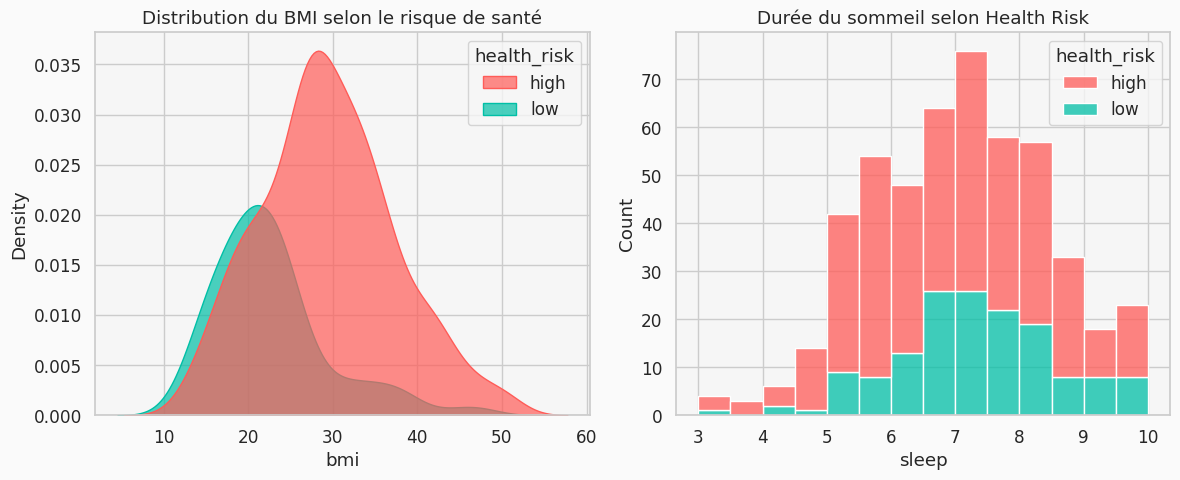

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Thème global professionnel
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.1)

# Palette unique pour tout le projet
palette = {"low": "#00BFA6", "high": "#FF5C58"}

# Couleur de fond douce
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F6F6F6'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data=sample_stratified, x='bmi', hue='health_risk', fill=True, palette=palette, alpha=0.7, ax=axes[0])
axes[0].set_title("Distribution du BMI selon le risque de santé")

sns.histplot(data=sample_stratified, x='sleep', hue='health_risk', multiple='stack', palette=palette, ax=axes[1])
axes[1].set_title("Durée du sommeil selon Health Risk")
plt.tight_layout()
plt.show()


C:\Users\merry b\AppData\Local\Temp\ipykernel_20500\3902661775.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


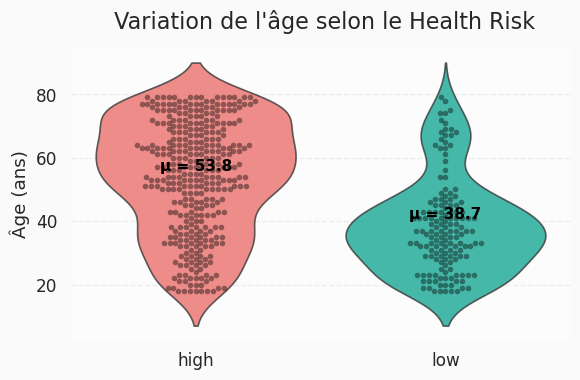

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Thème global professionnel
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.1)

# Palette unique pour tout le projet
palette = {"low": "#00BFA6", "high": "#FF5C58"}

# Couleur de fond douce
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F6F6F6'

# Création du violon “haut de gamme”
plt.figure(figsize=(6,4))

sns.violinplot(
    data=sample_stratified,
    x='health_risk',
    y='age',
    palette=palette,
    inner=None,              # on cache les points internes pour plus de pureté visuelle
    linewidth=1.2,
    alpha=0.8
)

# Ajout d’un swarmplot au-dessus pour l’effet “vivant”
sns.swarmplot(
    data=sample_stratified,
    x='health_risk',
    y='age',
    color='black',
    alpha=0.4,
    size=4
)

# Ajout des moyennes
means = sample_stratified.groupby('health_risk')['age'].mean()
for i, risk in enumerate(means.index):
    plt.text(i, means[risk]+1, f"µ = {means[risk]:.1f}", ha='center', va='bottom',
             color='black', fontsize=11, fontweight='bold')

# Design final
plt.title(" Variation de l'âge selon le Health Risk", fontsize=16, pad=15)
plt.xlabel("")
plt.ylabel("Âge (ans)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Fond dégradé subtil
ax = plt.gca()
ax.set_facecolor("#FDFDFD")
ax.patch.set_alpha(0.9)

# Effet d'ombre douce
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

In [158]:
import scipy.stats as stats
import numpy as np
import pandas as pd

# ---  Séparation des groupes ---
group_low = sample_stratified[sample_stratified['health_risk'] == 'low']['age']
group_high = sample_stratified[sample_stratified['health_risk'] == 'high']['age']

# ---  Vérification des conditions du test ---
# Normalité des distributions (test de Shapiro)
shapiro_low = stats.shapiro(group_low)
shapiro_high = stats.shapiro(group_high)

# Homogénéité des variances (test de Levene)
levene_test = stats.levene(group_low, group_high)

print("Test de Shapiro (low): p =", round(shapiro_low.pvalue, 4))
print("Test de Shapiro (high): p =", round(shapiro_high.pvalue, 4))
print("Test de Levene (égalité des variances): p =", round(levene_test.pvalue, 4))

# ---  Test de Student (indépendant) ---
t_stat, p_value = stats.ttest_ind(group_low, group_high, equal_var=levene_test.pvalue > 0.05)

# ---  Résumé statistique ---
mean_low = group_low.mean()
mean_high = group_high.mean()

print("\nMoyenne (low risk):", round(mean_low, 2))
print("Moyenne (high risk):", round(mean_high, 2))
print("t-statistique:", round(t_stat, 3))
print("p-value:", format(p_value, ".4f"))

# ---  Interprétation automatique ---
alpha = 0.05
if p_value < alpha:
    print("\n On rejette H₀ : la différence d'âge moyen est significative.")
    print(f"→ Les individus à risque élevé ({mean_high:.1f} ans) sont significativement plus âgés que ceux à risque faible ({mean_low:.1f} ans).")
else:
    print("\n On ne rejette pas H₀ : pas de différence significative entre les groupes.")

Test de Shapiro (low): p = 0.0
Test de Shapiro (high): p = 0.0
Test de Levene (égalité des variances): p = 0.0004

Moyenne (low risk): 38.7
Moyenne (high risk): 53.85
t-statistique: -9.83
p-value: 0.0000

 On rejette H₀ : la différence d'âge moyen est significative.
→ Les individus à risque élevé (53.8 ans) sont significativement plus âgés que ceux à risque faible (38.7 ans).


> Le test de Student a révélé une différence significative d’âge moyen entre les deux groupes de risque.
En effet, l’âge moyen est de 53,8 ans pour le groupe à risque élevé contre 38,7 ans pour le groupe à faible risque (p < 0.001).
Ce résultat confirme visuellement ce que suggérait le graphique en violon : les individus plus âgés présentent un risque de santé plus élevé.

C:\Users\merry b\AppData\Local\Temp\ipykernel_20500\3683497760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='health_risk', y='weight', data=sample_stratified, palette=palette, width=0.5)


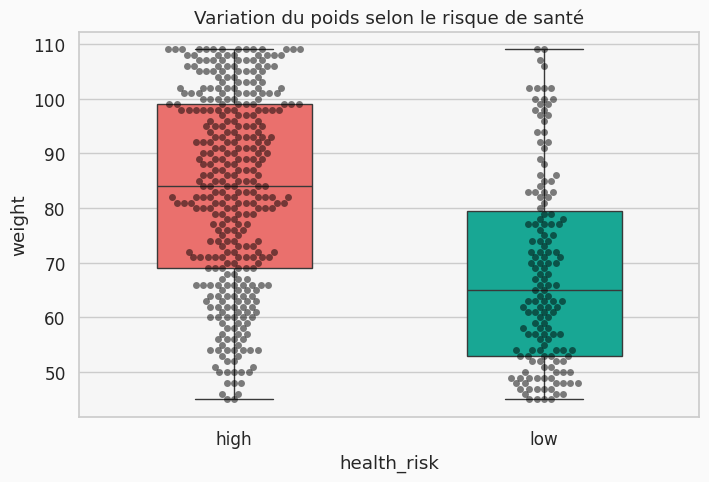

In [126]:
plt.figure(figsize=(8,5))
sns.boxplot(x='health_risk', y='weight', data=sample_stratified, palette=palette, width=0.5)
sns.swarmplot(x='health_risk', y='weight', data=sample_stratified, color='black', alpha=0.5)
plt.title("Variation du poids selon le risque de santé")
plt.show()

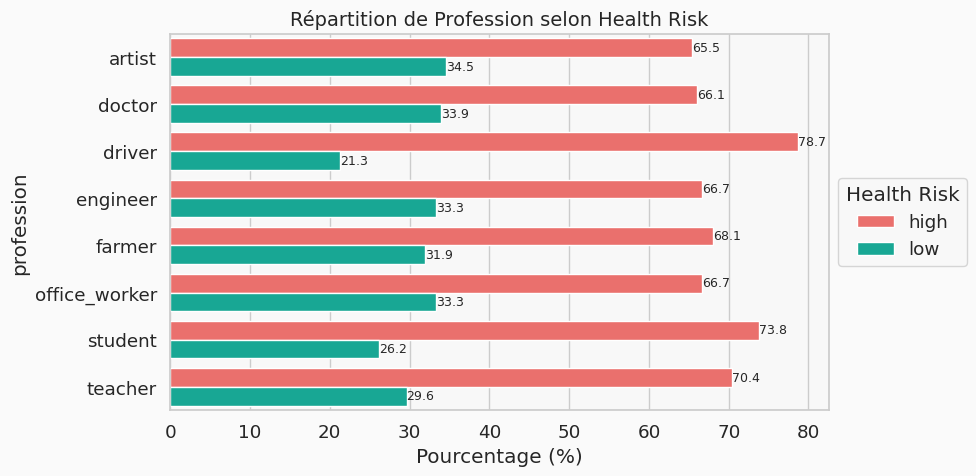

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
palette = {"low": "#00BFA6", "high": "#FF5C58"}  # turquoise vs rouge
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F8F8'

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = 'profession'  # tu peux changer par 'alcohol', 'smoking', 'sugar_intake'

# Calcul des pourcentages sans problème d'index
data_prop = (
    sample_stratified.groupby([cat, 'health_risk'])
    .size()
    .reset_index(name='count')
)

# transform() conserve le bon index
data_prop['percentage'] = data_prop.groupby(cat)['count'].transform(lambda x: 100 * x / x.sum())

# ======= Visualisation =======
plt.figure(figsize=(10, 5))
sns.barplot(data=data_prop, x='percentage', y=cat, hue='health_risk', palette=palette)
plt.title(f"Répartition de {cat.capitalize()} selon Health Risk", size=14)
plt.xlabel("Pourcentage (%)")

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9)

plt.legend(title="Health Risk", bbox_to_anchor=(1.0, 0.5), loc='center left')
plt.tight_layout()
plt.show()


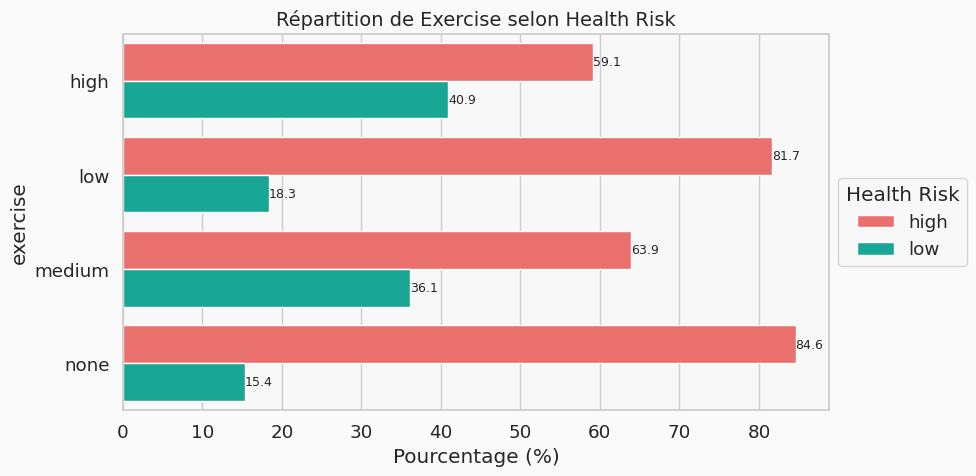

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.2)
palette = {"low": "#00BFA6", "high": "#FF5C58"}  # turquoise vs rouge
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F8F8'

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = 'exercise'  # tu peux changer par 'alcohol', 'smoking', 'sugar_intake'

# Calcul des pourcentages sans problème d'index
data_prop = (
    sample_stratified.groupby([cat, 'health_risk'])
    .size()
    .reset_index(name='count')
)

# transform() conserve le bon index
data_prop['percentage'] = data_prop.groupby(cat)['count'].transform(lambda x: 100 * x / x.sum())

# ======= Visualisation =======
plt.figure(figsize=(10, 5))
sns.barplot(data=data_prop, x='percentage', y=cat, hue='health_risk', palette=palette)
plt.title(f"Répartition de {cat.capitalize()} selon Health Risk", size=14)
plt.xlabel("Pourcentage (%)")

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f', label_type='edge', fontsize=9)

plt.legend(title="Health Risk", bbox_to_anchor=(1.0, 0.5), loc='center left')
plt.tight_layout()
plt.show()

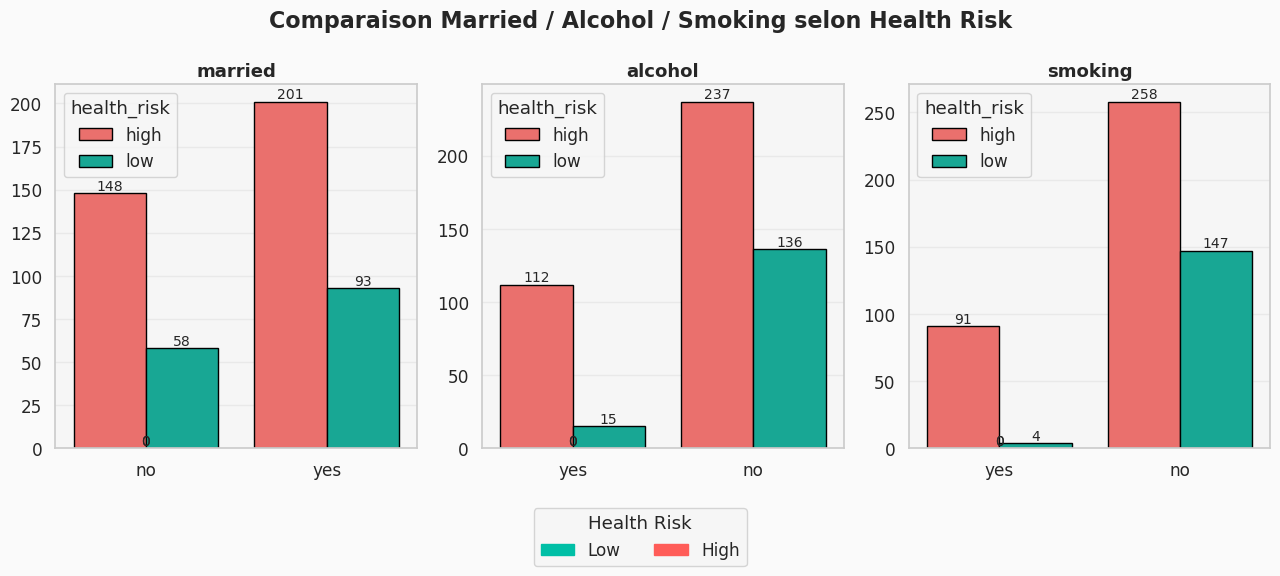

In [154]:
cols = ['married','alcohol','smoking']
fig, axes = plt.subplots(1, 3, figsize=(13,5))

for ax, col in zip(axes, cols):
    sns.countplot(data=sample_stratified, x=col, hue='health_risk', 
                  palette=palette, edgecolor='black', ax=ax)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)
    ax.set_title(f"{col}", fontsize=13, weight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Comparaison Married / Alcohol / Smoking selon Health Risk", fontsize=16, weight='bold')
fig.legend(title='Health Risk', handles=[
    mpatches.Patch(color=palette['low'], label='Low'),
    mpatches.Patch(color=palette['high'], label='High')],
    loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.show()


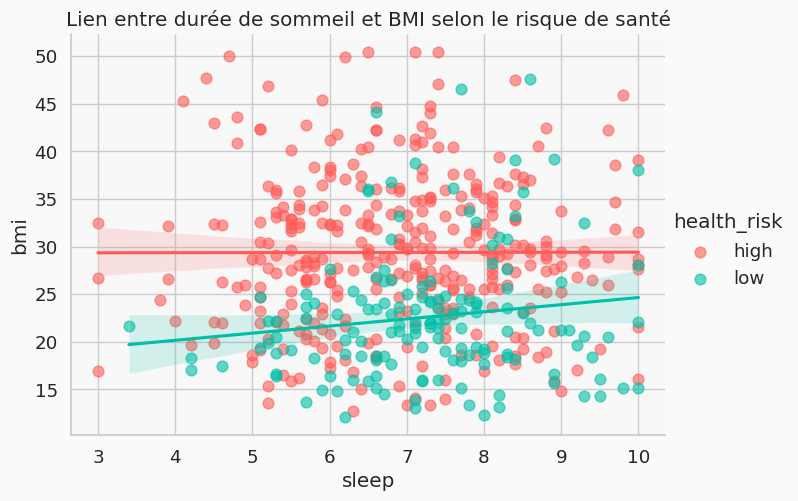

In [102]:
sns.lmplot(data=sample_stratified, x='sleep', y='bmi', hue='health_risk',
           palette=palette, aspect=1.4, height=5, scatter_kws={'alpha':0.6, 's':60})
plt.title("Lien entre durée de sommeil et BMI selon le risque de santé")
plt.show()

In [225]:
import scipy.stats as stats

# --- Sélection des variables ---
x = sample_stratified['bmi']
y = sample_stratified['sleep']

# --- Calcul du coefficient de corrélation de Pearson ---
r, p_value = stats.pearsonr(x, y)

print("Corrélation entre BMI et Sleep")
print("Coefficient de Pearson (r):", round(r, 3))
print("p-value:", format(p_value, ".4f"))

# --- Interprétation automatique ---
if p_value < 0.05:
    print("Corrélation significative.")
else:
    print("Corrélation non significative.")

if abs(r) < 0.3:
    strength = "faible"
elif abs(r) < 0.7:
    strength = "modérée"
else:
    strength = "forte"

direction = "positive" if r > 0 else "négative"

print(f"→ Relation {strength} et {direction} entre BMI et durée de sommeil.")


Corrélation entre BMI et Sleep
Coefficient de Pearson (r): -0.016
p-value: 0.7173
Corrélation non significative.
→ Relation faible et négative entre BMI et durée de sommeil.


> Bien que la visualisation suggère une faible relation entre sommeil et BMI, 
le coefficient de Pearson (r = -0.02, p = 0.72) confirme l'absence de corrélation linéaire significative.

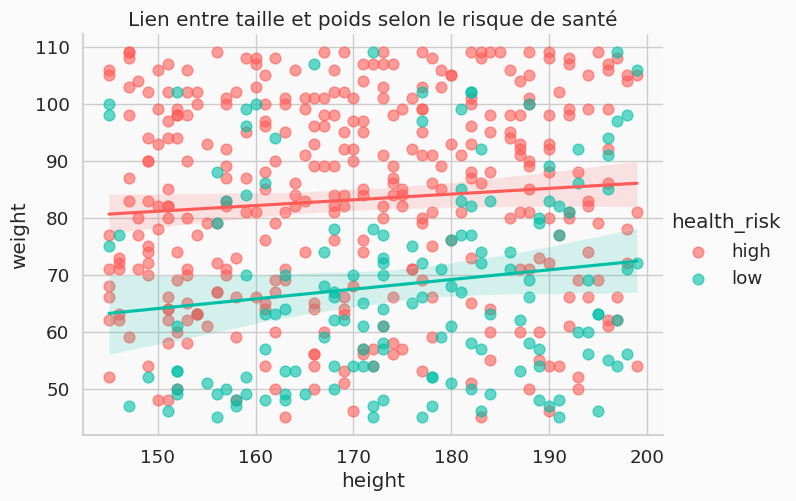

In [116]:
sns.lmplot(data=sample_stratified, x='height', y='weight', hue='health_risk',
           palette=palette, aspect=1.4, height=5, scatter_kws={'alpha':0.6, 's':60})
plt.title("Lien entre taille et poids selon le risque de santé")
plt.show()

## Visualisations multivariées

Les visualisations multivariées permettent d'explorer les interactions complexes entre plusieurs variables simultanément.

### Objectifs :
- Comprendre les interactions entre variables
- Identifier des patterns multifactoriels
- Révéler des effets de modération
- Appréhender la complexité du risque de santé

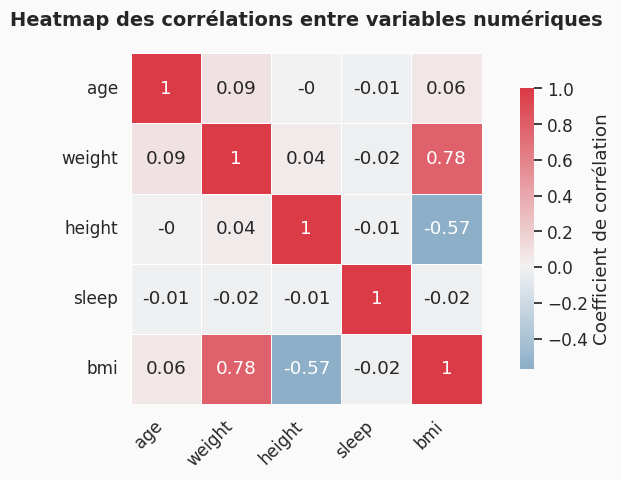

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Thème global cohérent
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.1)
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#F8F9FA'

# Palette de corrélation douce et lisible
cmap = sns.diverging_palette(240, 10, as_cmap=True)

# Sélection des colonnes numériques (int + float)
num_cols = sample_stratified.select_dtypes(include=['int64', 'float64']).columns

# Calcul de la matrice de corrélation
corr = sample_stratified[num_cols].corr().round(2)

# Heatmap bien structurée
plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    annot=True,          # afficher les coefficients
    cmap=cmap,           # palette
    center=0,            # centrer autour de 0
    linewidths=0.6,      # séparateurs entre cases
    square=True,         # cases carrées
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de corrélation'}
)

plt.title("Heatmap des corrélations entre variables numériques", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

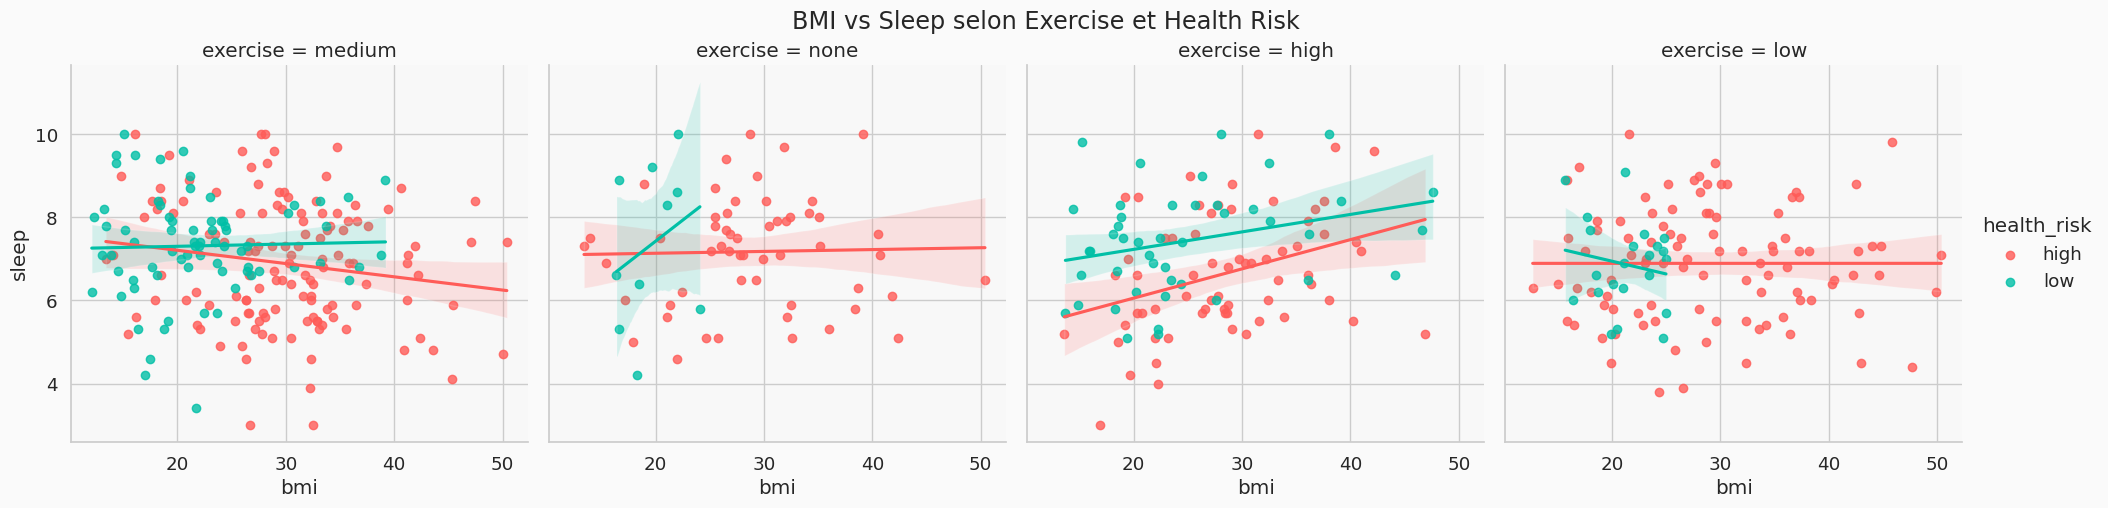

In [57]:
sns.lmplot(data=sample_stratified, x='bmi', y='sleep', hue='health_risk', col='exercise', palette=palette)
plt.suptitle("BMI vs Sleep selon Exercise et Health Risk", y=1.02)
plt.show()

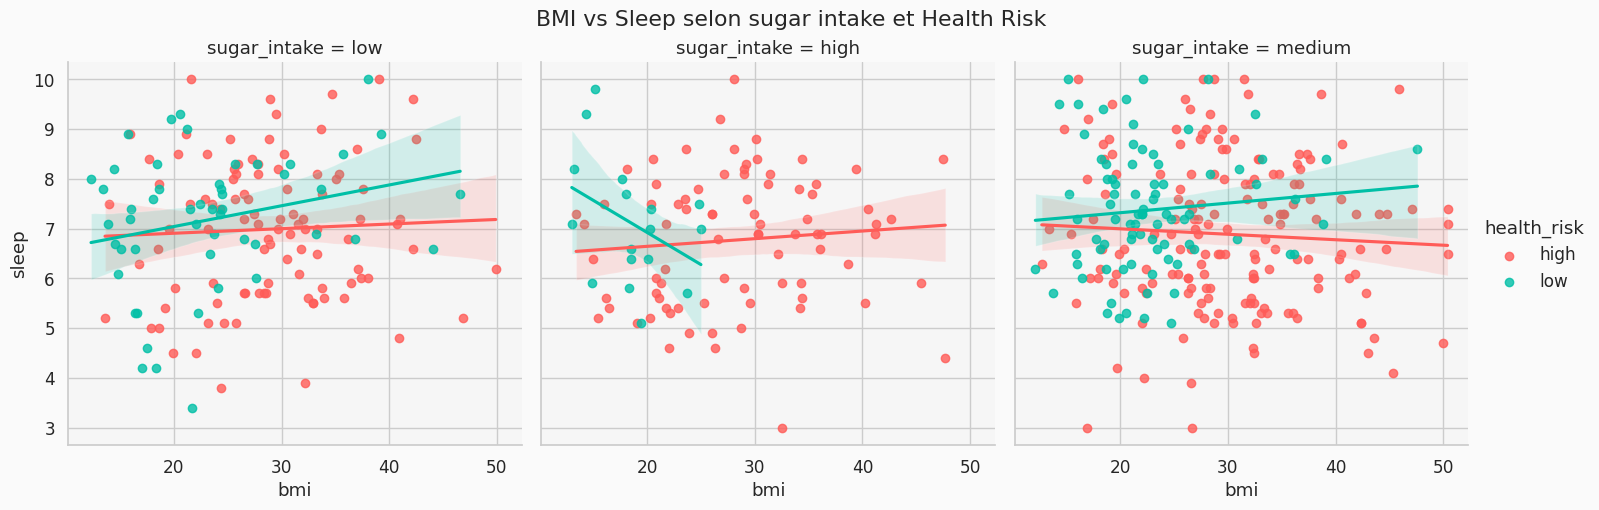

In [132]:
sns.lmplot(data=sample_stratified, x='bmi', y='sleep', hue='health_risk', col='sugar_intake', palette=palette)
plt.suptitle("BMI vs Sleep selon sugar intake et Health Risk", y=1.02)
plt.show()

## Synthèse des résultats

### Facteurs principaux associés au risque de santé élevé

#### Facteurs physiologiques :
1. **IMC élevé (>30)** : Facteur le plus discriminant
2. **Poids élevé** : ~20 kg de différence médiane
3. **Âge avancé** : ~15 ans de différence moyenne

#### Comportements à risque :
1. **Tabagisme** : 96% de risque élevé (quasi-déterministe)
2. **Consommation d'alcool** : 88% de risque élevé
3. **Absence d'exercice** : 84,6% de risque élevé

#### Facteurs modérés :
- Durée de sommeil (effet faible mais présent)
- Profession (certaines plus exposées)
- Consommation de sucre (modérateur d'autres effets)

### Interactions identifiées

- L'exercice modère la relation sommeil-IMC
- La consommation de sucre influence l'efficacité du sommeil
- L'âge peut agir comme facteur confondant

### Forces de l'échantillonnage stratifié

 Préservation des proportions  
 Représentativité garantie  
 Analyses comparatives robustes  
 Taille suffisante (500 obs)

## Conclusions

### Principaux enseignements

Ce projet de visualisation a permis d'identifier les facteurs de risque principaux à travers une exploration méthodique en trois phases :

1. **Visualisations univariées** : L'IMC, le poids et l'âge se distinguent comme facteurs physiologiques majeurs

2. **Visualisations bivariées** : Le tabagisme, l'alcool et l'absence d'exercice montrent les associations les plus fortes avec le risque élevé

3. **Visualisations multivariées** : Des interactions complexes existent entre exercice, sommeil, sucre et IMC

### Pertinence de l'approche

L'**échantillonnage stratifié** s'est révélé être le choix méthodologique approprié en garantissant la représentativité des deux groupes de risque. La progression univariée → bivariée → multivariée a permis une compréhension progressive et approfondie des données.

### 8.3 Limites identifiées

- Variables catégorielles imprécises (définitions de "low", "medium", "high")
- Données transversales (pas de causalité établie)
- Déséquilibre entre les groupes de risque

### Recommandations

Pour améliorer ce projet :
- Collecter des variables supplémentaires (qualité du sommeil, composition corporelle)
- Réaliser des analyses stratifiées par âge
- Utiliser des données longitudinales pour établir la causalité

### Conclusion finale

Le risque de santé apparaît comme un **phénomène multifactoriel** résultant de l'accumulation de plusieurs facteurs défavorables plutôt que de l'effet isolé d'un seul déterminant. Une approche de prévention intégrée ciblant simultanément l'alimentation, l'activité physique, et l'abstinence tabagique et alcoolique serait plus efficace que des interventions isolées.

---

**Projet réalisé dans le cadre du module Visualisations des données**  
**Date** : 26/10/2025 
**Étudiante** : MARIAM BOURCHOUK